# Notebook 02 — Regresión lineal

## Objetivos

Al finalizar este notebook deberías ser capaz de:

- ajustar una regresión lineal con `scikit-learn`;
- interpretar intercepto y coeficientes;
- generar predicciones;
- evaluar el modelo y analizar residuos;
- obtener un resumen estadístico con `statsmodels`;
- construir intervalos de confianza e intervalos de predicción;
- extender el análisis a regresión múltiple.

Usaremos datos sintéticos para conocer los parámetros verdaderos del proceso generador.

## 1. Importación de librerías

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import statsmodels.api as sm

RANDOM_STATE = 42
pd.options.display.float_format = "{:,.3f}".format


## 2. Generación de datos sintéticos

Generaremos una relación lineal simple:

\[
y=\beta_0+\beta_1x+\varepsilon.
\]

El parámetro `coef=True` permite recuperar el coeficiente verdadero.

In [6]:
X, y, true_coef = make_regression(
    n_samples=250,
    n_features=1,
    n_informative=1,
    noise=18,
    bias=25,
    coef=True,
    random_state=RANDOM_STATE,
)

true_intercept = 25.0
true_slope = float(true_coef)

print(f"Intercepto verdadero: {true_intercept:.3f}")
print(f"Pendiente verdadera: {true_slope:.3f}")
print(f"Dimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")


Intercepto verdadero: 25.000
Pendiente verdadera: 66.020
Dimensión de X: (250, 1)
Dimensión de y: (250,)


In [7]:
data = pd.DataFrame({"x": X[:, 0], "y": y})
data.head()


,x,y
0,0.005,-0.683
1,0.341,71.543
2,-0.562,11.697
3,1.466,129.051
4,0.856,75.791


In [8]:
data.describe()

,x,y
count,250.000,250.000
mean,-0.002,26.149
std,0.966,67.801
min,-2.620,-185.575
25%,-0.679,-17.269
50%,0.059,27.547
75%,0.583,66.643
max,3.853,257.251


## 3. Exploración visual

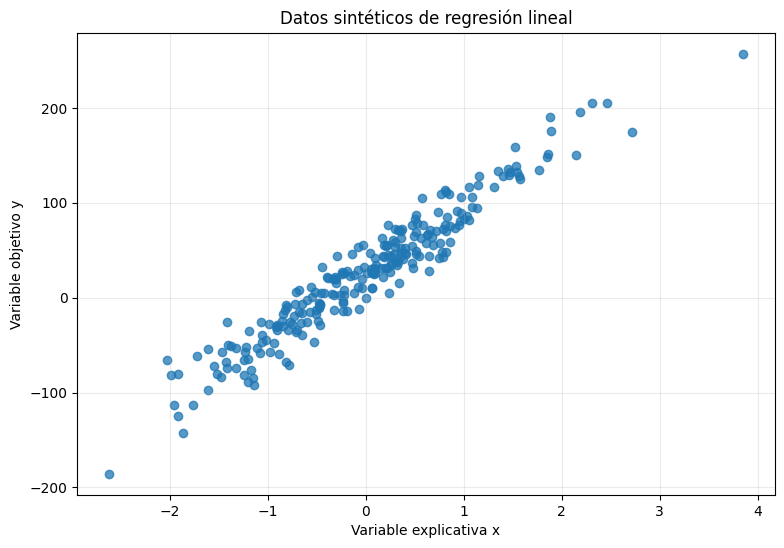

In [9]:
plt.figure(figsize=(9, 6))
plt.scatter(data["x"], data["y"], alpha=0.75)
plt.xlabel("Variable explicativa x")
plt.ylabel("Variable objetivo y")
plt.title("Datos sintéticos de regresión lineal")
plt.grid(alpha=0.25)
plt.show()


> **Observación:** una relación visual no implica causalidad. La regresión lineal describe asociación predictiva salvo que exista un diseño causal que justifique otra interpretación.

## 4. Separación en entrenamiento y prueba

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Observaciones de entrenamiento: {len(X_train)}")
print(f"Observaciones de prueba: {len(X_test)}")


Observaciones de entrenamiento: 187
Observaciones de prueba: 63


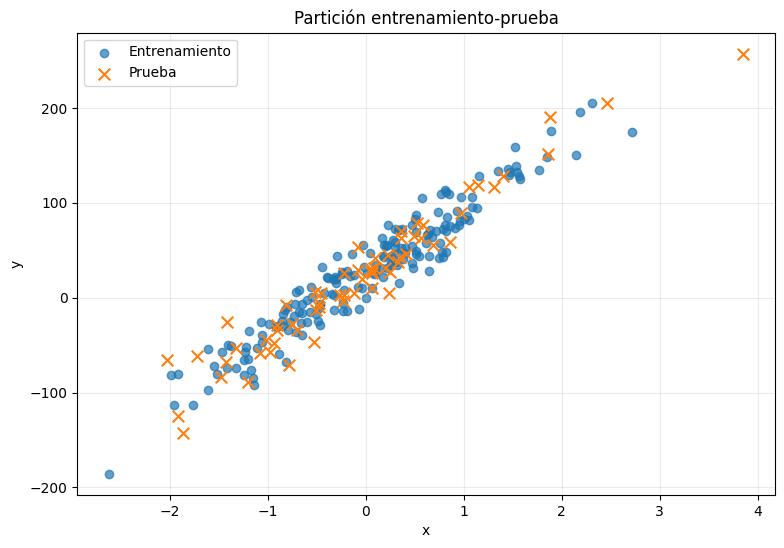

In [11]:
plt.figure(figsize=(9, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.7, label="Entrenamiento")
plt.scatter(X_test[:, 0], y_test, marker="x", s=70, label="Prueba")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Partición entrenamiento-prueba")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 5. Ajuste con `scikit-learn`

\[
\widehat y=\widehat\beta_0+\widehat\beta_1x.
\]

La interfaz básica es: crear el estimador, ajustar con `fit` y predecir con `predict`.

In [12]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

estimated_intercept = float(sklearn_model.intercept_)
estimated_slope = float(sklearn_model.coef_[0])

print(f"Intercepto estimado: {estimated_intercept:.3f}")
print(f"Pendiente estimada: {estimated_slope:.3f}")


Intercepto estimado: 26.814
Pendiente estimada: 67.317


In [13]:
parameter_comparison = pd.DataFrame({
    "Parámetro": ["Intercepto", "Pendiente"],
    "Valor verdadero": [true_intercept, true_slope],
    "Valor estimado": [estimated_intercept, estimated_slope],
})
parameter_comparison["Error de estimación"] = (
    parameter_comparison["Valor estimado"] - parameter_comparison["Valor verdadero"]
)
parameter_comparison


,Parámetro,Valor verdadero,Valor estimado,Error de estimación
0,Intercepto,25.000,26.814,1.814
1,Pendiente,66.020,67.317,1.297


### Interpretación

- El intercepto es la predicción cuando \(x=0\).
- La pendiente es el cambio esperado en \(\widehat y\) cuando \(x\) aumenta una unidad.

## 6. Predicciones

In [14]:
y_pred = sklearn_model.predict(X_test)

predictions = pd.DataFrame({
    "x": X_test[:, 0],
    "y_real": y_test,
    "y_predicha": y_pred,
})
predictions["residuo"] = predictions["y_real"] - predictions["y_predicha"]
predictions.head(10)


,x,y_real,y_predicha,residuo
0,-1.913,-124.718,-101.982,-22.735
1,0.587,77.099,66.320,10.780
2,-1.320,-52.537,-62.075,9.538
3,0.969,88.868,92.020,-3.153
4,-1.078,-57.931,-45.737,-12.195
5,-0.234,-3.612,11.052,-14.664
6,-0.461,4.520,-4.195,8.715
7,-1.867,-142.498,-98.885,-43.613
8,0.227,44.686,42.126,2.560
9,-0.938,-48.082,-36.318,-11.764


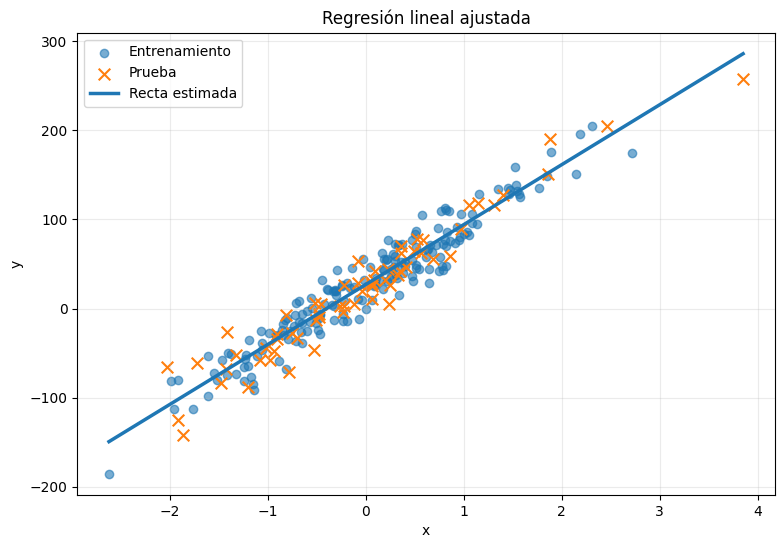

In [15]:
x_line = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_line = sklearn_model.predict(x_line)

plt.figure(figsize=(9, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.6, label="Entrenamiento")
plt.scatter(X_test[:, 0], y_test, marker="x", s=70, label="Prueba")
plt.plot(x_line[:, 0], y_line, linewidth=2.5, label="Recta estimada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresión lineal ajustada")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Evaluación predictiva

In [16]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [mae, rmse, r2],
})


,Métrica,Valor
0,MAE,14.501
1,RMSE,19.016
2,R²,0.935


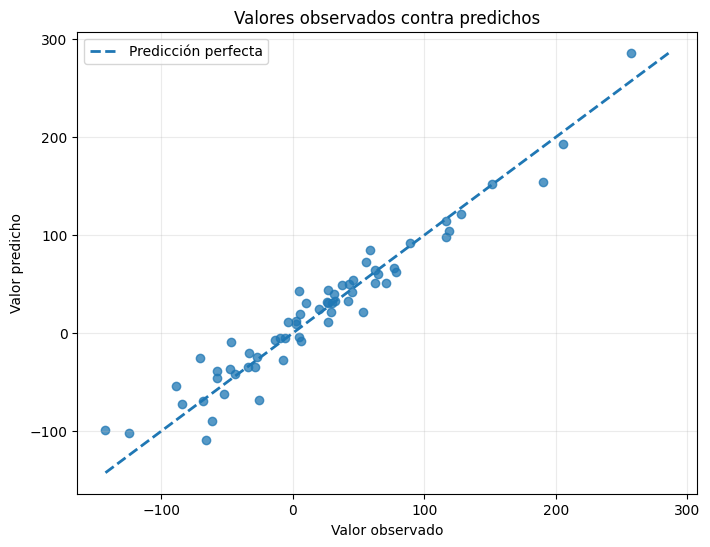

In [17]:
minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.75)
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Predicción perfecta",
)
plt.xlabel("Valor observado")
plt.ylabel("Valor predicho")
plt.title("Valores observados contra predichos")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Análisis de residuos

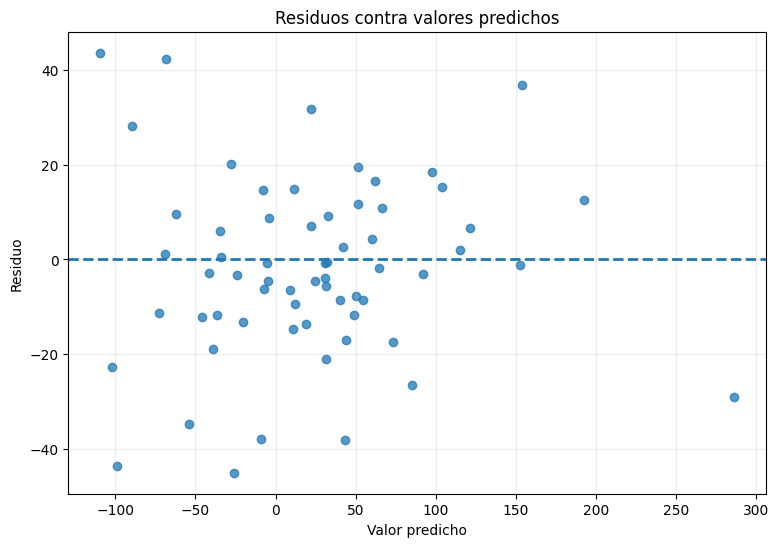

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Residuos contra valores predichos")
plt.grid(alpha=0.25)
plt.show()


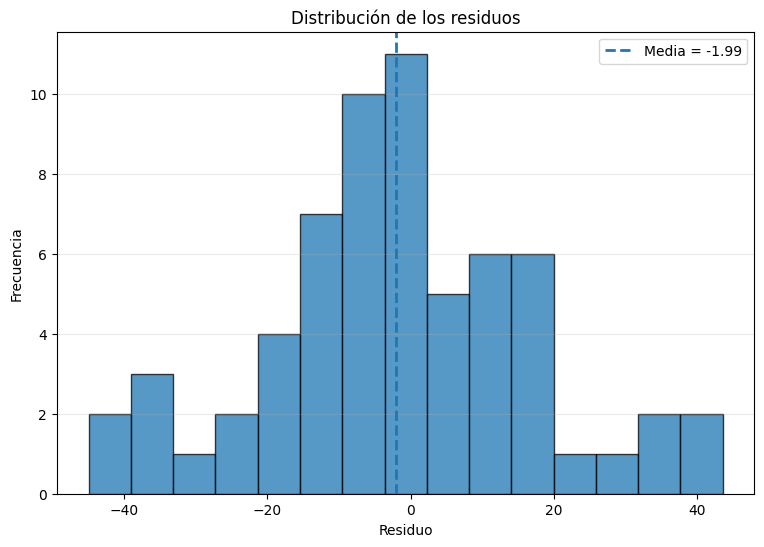

In [19]:
plt.figure(figsize=(9, 6))
plt.hist(residuals, bins=15, edgecolor="black", alpha=0.75)
plt.axvline(
    residuals.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media = {residuals.mean():.2f}",
)
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## 9. Ajuste con `statsmodels`

`scikit-learn` está orientado a predicción y pipelines.  
`statsmodels` añade errores estándar, pruebas, intervalos y `summary()`.

In [20]:
X_train_sm = sm.add_constant(X_train)
stats_model = sm.OLS(y_train, X_train_sm)
stats_results = stats_model.fit()

stats_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.923
Model:                            OLS   Adj. R-squared:                  0.922
Method:                 Least Squares   F-statistic:                     2209.
Date:                Fri, 31 Jul 2026   Prob (F-statistic):          8.56e-105
Time:                        16:30:13   Log-Likelihood:                -806.46
No. Observations:                 187   AIC:                             1617.
Df Residuals:                     185   BIC:                             1623.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.8140      1.328     20.190      0.000      24.194      29.434
x1            67.3171      1.432     46.998      0.000      64.491      70.143
==============================================================================
Omnibus:                        3.897   Durbin-Watson:                   2.075
Prob(Omnibus):                  0.143   Jarque-Bera (JB):                2.787
Skew:                          -0.141   Prob(JB):                        0.248
Kurtosis:                       2.473   Cond. No.                         1.08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Cómo leer el resumen

- `coef`: estimación;
- `std err`: error estándar;
- `t`: estadístico de prueba;
- `P>|t|`: valor \(p\);
- `[0.025, 0.975]`: intervalo de confianza al 95%;
- `R-squared`: proporción de variabilidad explicada.

> Un valor \(p\) pequeño no demuestra causalidad ni importancia práctica.

In [21]:
stats_parameters = pd.DataFrame({
    "Parámetro": ["Intercepto", "Pendiente"],
    "Estimación sklearn": [sklearn_model.intercept_, sklearn_model.coef_[0]],
    "Estimación statsmodels": stats_results.params,
})
stats_parameters["Diferencia"] = (
    stats_parameters["Estimación sklearn"]
    - stats_parameters["Estimación statsmodels"]
)
stats_parameters


,Parámetro,Estimación sklearn,Estimación statsmodels,Diferencia
0,Intercepto,26.814,26.814,-0.000
1,Pendiente,67.317,67.317,0.000


## 10. Intervalos de confianza de los coeficientes

In [22]:
confidence_intervals = stats_results.conf_int(alpha=0.05)

pd.DataFrame({
    "Parámetro": ["Intercepto", "Pendiente"],
    "Estimación": stats_results.params,
    "Límite inferior 95%": confidence_intervals[:, 0],
    "Límite superior 95%": confidence_intervals[:, 1],
})


,Parámetro,Estimación,Límite inferior 95%,Límite superior 95%
0,Intercepto,26.814,24.194,29.434
1,Pendiente,67.317,64.491,70.143


## 11. Predicción de nuevas observaciones

In [23]:
new_data = pd.DataFrame({"x": [-2.0, 0.0, 1.5, 3.0]})
new_data["Predicción sklearn"] = sklearn_model.predict(new_data[["x"]].to_numpy())
new_data


,x,Predicción sklearn
0,-2.000,-107.820
1,0.000,26.814
2,1.500,127.790
3,3.000,228.765


## 12. Intervalos de confianza e intervalos de predicción

- El intervalo de confianza describe incertidumbre sobre la media esperada.
- El intervalo de predicción describe incertidumbre sobre una observación individual.

El intervalo de predicción suele ser más amplio.

In [24]:
new_X_sm = sm.add_constant(new_data[["x"]].to_numpy(), has_constant="add")
prediction_summary = stats_results.get_prediction(new_X_sm).summary_frame(alpha=0.05)

pd.DataFrame({
    "x": new_data["x"],
    "Predicción": prediction_summary["mean"].to_numpy(),
    "IC media inferior": prediction_summary["mean_ci_lower"].to_numpy(),
    "IC media superior": prediction_summary["mean_ci_upper"].to_numpy(),
    "IP inferior": prediction_summary["obs_ci_lower"].to_numpy(),
    "IP superior": prediction_summary["obs_ci_upper"].to_numpy(),
})


,x,Predicción,IC media inferior,IC media superior,IP inferior,IP superior
0,-2.000,-107.820,-114.104,-101.536,-144.188,-71.453
1,0.000,26.814,24.194,29.434,-9.102,62.730
2,1.500,127.790,122.858,132.721,91.631,163.948
3,3.000,228.765,219.950,237.580,191.876,265.655


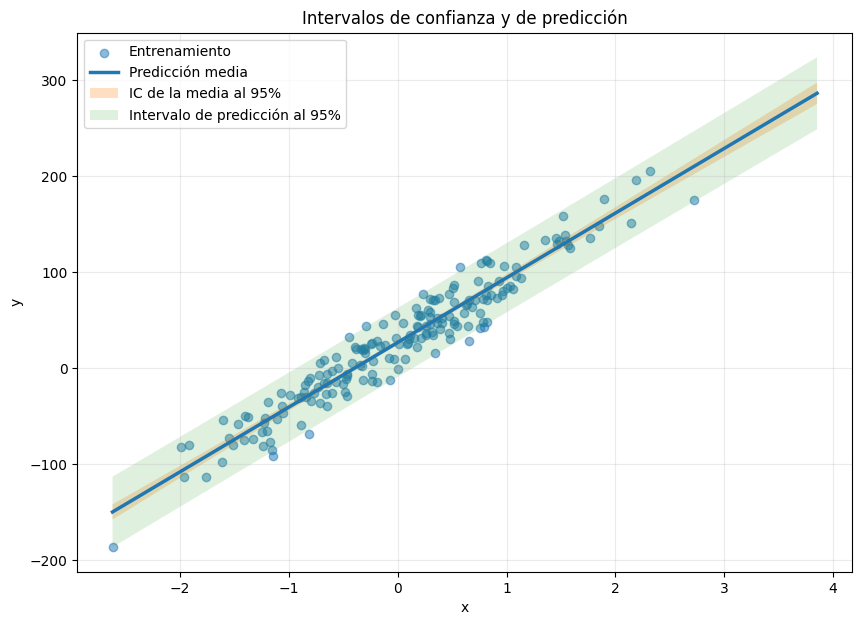

In [25]:
x_grid = np.linspace(X.min(), X.max(), 300)
x_grid_sm = sm.add_constant(x_grid, has_constant="add")
grid_summary = stats_results.get_prediction(x_grid_sm).summary_frame(alpha=0.05)

plt.figure(figsize=(10, 7))
plt.scatter(X_train[:, 0], y_train, alpha=0.5, label="Entrenamiento")
plt.plot(x_grid, grid_summary["mean"], linewidth=2.5, label="Predicción media")
plt.fill_between(
    x_grid,
    grid_summary["mean_ci_lower"],
    grid_summary["mean_ci_upper"],
    alpha=0.25,
    label="IC de la media al 95%",
)
plt.fill_between(
    x_grid,
    grid_summary["obs_ci_lower"],
    grid_summary["obs_ci_upper"],
    alpha=0.15,
    label="Intervalo de predicción al 95%",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Intervalos de confianza y de predicción")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 13. Regresión lineal múltiple

\[
\widehat y
=
\widehat\beta_0+
\widehat\beta_1x_1+\cdots+\widehat\beta_px_p.
\]

El coeficiente de \(x_j\) se interpreta manteniendo constantes las demás variables.

In [26]:
X_multi, y_multi, true_coefs_multi = make_regression(
    n_samples=350,
    n_features=4,
    n_informative=4,
    noise=20,
    bias=10,
    coef=True,
    random_state=RANDOM_STATE,
)

feature_names = [f"x_{i}" for i in range(1, X_multi.shape[1] + 1)]
X_multi_df = pd.DataFrame(X_multi, columns=feature_names)
y_multi_series = pd.Series(y_multi, name="y")

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi_df,
    y_multi_series,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_multi)
multi_predictions = multi_model.predict(X_test_multi)

multi_results = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente verdadero": true_coefs_multi,
    "Coeficiente estimado": multi_model.coef_,
})
multi_results["Diferencia"] = (
    multi_results["Coeficiente estimado"]
    - multi_results["Coeficiente verdadero"]
)
multi_results


,Variable,Coeficiente verdadero,Coeficiente estimado,Diferencia
0,x_1,66.137,67.059,0.922
1,x_2,17.411,17.074,-0.337
2,x_3,9.840,9.374,-0.465
3,x_4,18.520,18.910,0.391


In [27]:
pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor": [
        mean_absolute_error(y_test_multi, multi_predictions),
        mean_squared_error(y_test_multi, multi_predictions) ** 0.5,
        r2_score(y_test_multi, multi_predictions),
    ],
})


,Métrica,Valor
0,MAE,16.499
1,RMSE,20.017
2,R²,0.920


## 14. Errores conceptuales frecuentes

1. Interpretar asociación como causalidad.
2. Considerar que un \(R^2\) alto garantiza un buen modelo.
3. Evaluar únicamente con datos de entrenamiento.
4. Extrapolar muy lejos del rango observado.
5. Ignorar patrones en residuos.
6. Confundir intervalo de confianza con intervalo de predicción.
7. Interpretar coeficientes sin considerar unidades.
8. Asumir que significancia estadística equivale a relevancia práctica.

## 15. Experimentos sugeridos

1. Cambia `noise` a 0, 10, 40 y 100.
2. Cambia `n_samples` a 25, 50, 500 y 5,000.
3. Genera una relación no lineal y examina los residuos.
4. Agrega una observación atípica y vuelve a estimar.
5. Multiplica una variable por 1,000 en la regresión múltiple y observa el coeficiente.

## 16. Resumen

En este notebook:

- ajustamos una regresión lineal con `scikit-learn`;
- interpretamos intercepto y pendiente;
- generamos predicciones;
- evaluamos el modelo;
- analizamos residuos;
- obtuvimos un `summary()` con `statsmodels`;
- construimos intervalos de confianza y de predicción;
- extendimos el análisis a regresión múltiple.